In [1]:
import pandas as pd
from cas import Cas, into_minutes, divide
flights = pd.read_csv("flights.csv", index_col="flightId")
airports = pd.read_csv("arrivalAirport.csv", index_col='fs')
aircrafts = pd.read_csv('equipment.csv', index_col='id')
flights['depTimeActual'] = flights['depTimeActual'].apply(Cas)
flights['depTimeScheduled'] = flights['depTimeScheduled'].apply(Cas)



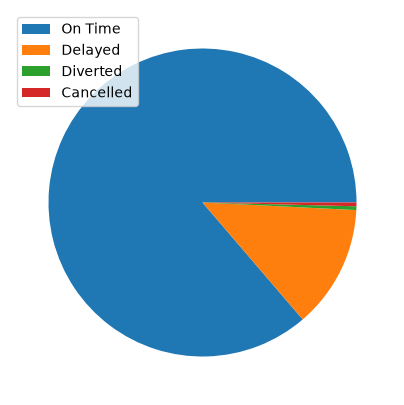

In [2]:
ax = flights["finalStatus"].value_counts().plot.pie(
    labels=None,
    figsize=(5, 5)
)
ax.legend(flights["finalStatus"].value_counts().index)

In [3]:
carrier_delays = flights[['depTimeActual', 'depTimeScheduled', 'carrier']]
carrier_delays['delay'] = carrier_delays['depTimeActual'] - carrier_delays['depTimeScheduled']
c1 = carrier_delays.groupby("carrier")["delay"].sum().rename('c1').sort_values()
c2 = carrier_delays.groupby("carrier")["delay"].count().rename('c2').sort_values()

merged = pd.merge(c1, c2, left_on='carrier', right_on='carrier')
#merged['average_delay'] = divide(merged['c1'], 2)
#merged['c1'] = merged['c1'].apply(Cas)
#merged['average_delay'] = divide(merged['c1'], 2)

In [6]:
carrier_delays = carrier_delays[['depTimeScheduled','delay']]
carrier_delays
carrier_delays['delay'] = carrier_delays['delay'].apply(into_minutes)
#carrier_delays


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Cas'

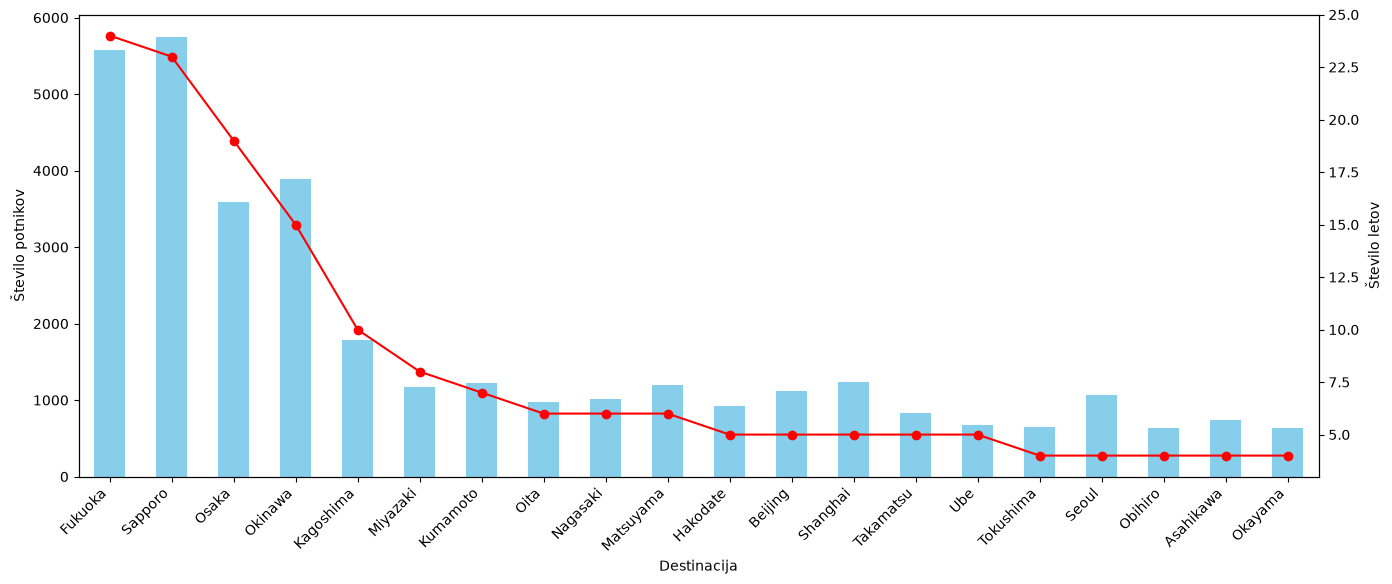

In [ ]:
m = pd.merge(flights, airports, left_on='arrivalAirportFS', right_on='fs')
merged = pd.merge(m, aircrafts, left_on='equipment', right_on='id')
t1 = (
    merged.groupby('city')['pax']
    .count()
    .rename('stevilo_letov')
    .sort_values(ascending=False))
t2 = (
    merged.groupby('city')['pax']
    .sum()
    .rename('stevilo_potnikov')
    .sort_values(ascending=False))
top_destinacije = pd.merge(t1, t2, left_on='city', right_on='city').head(20)

ax = top_destinacije["stevilo_potnikov"].plot.bar(figsize=(16, 6), color="skyblue")
top_destinacije["stevilo_letov"].plot(ax=ax, secondary_y=True, color="red", marker="o")
ax.set_xlabel('Destinacija')
ax.set_ylabel("Število potnikov")
ax.right_ax.set_ylabel("Število letov")
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

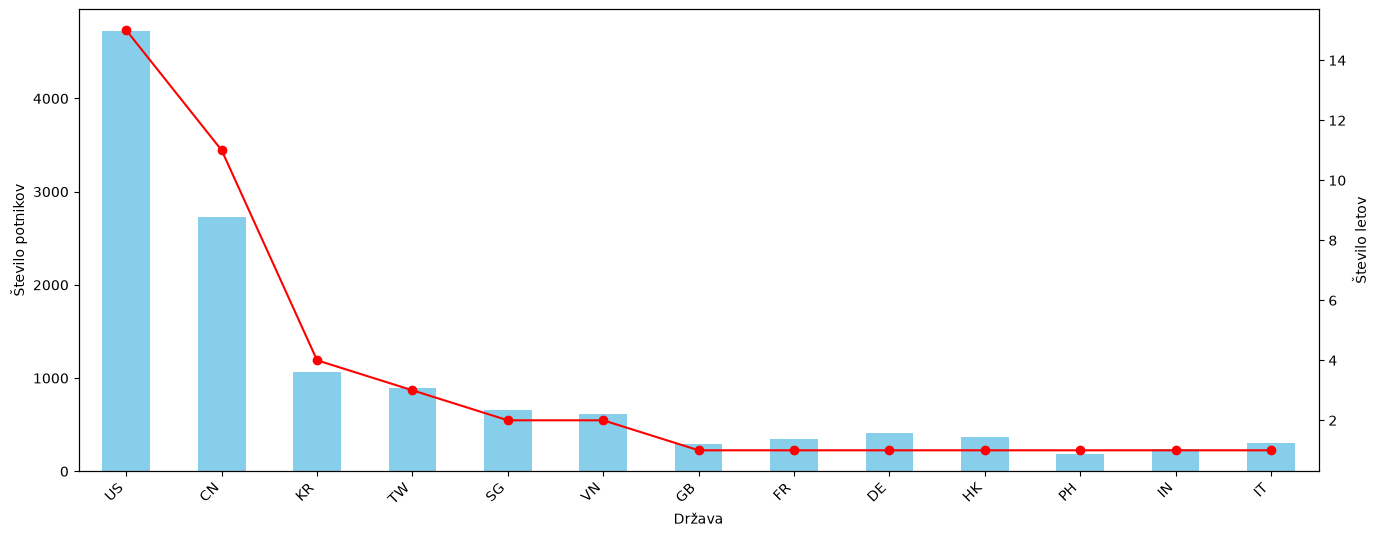

In [ ]:
m = pd.merge(flights, airports, left_on='arrivalAirportFS', right_on='fs')
merged = pd.merge(m, aircrafts, left_on='equipment', right_on='id')
merged = merged[merged['country'] != 'JP']
t1 = (
    merged.groupby('country')['pax']
    .count().rename('stevilo_letov')
    .sort_values(ascending=False))
t2 = (
    merged.groupby('country')['pax']
    .sum().rename('stevilo_potnikov')
    .sort_values(ascending=False))
top_destinacije = pd.merge(t1, t2, left_on='country', right_on='country').head(20)

ax = top_destinacije["stevilo_potnikov"].plot.bar(figsize=(16, 6), color="skyblue")
top_destinacije["stevilo_letov"].plot(ax=ax, secondary_y=True, color="red", marker="o")
ax.set_xlabel('Država')
ax.set_ylabel("Število potnikov")
ax.right_ax.set_ylabel("Število letov")
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

Text(0, 0.5, 'Trajanje leta')

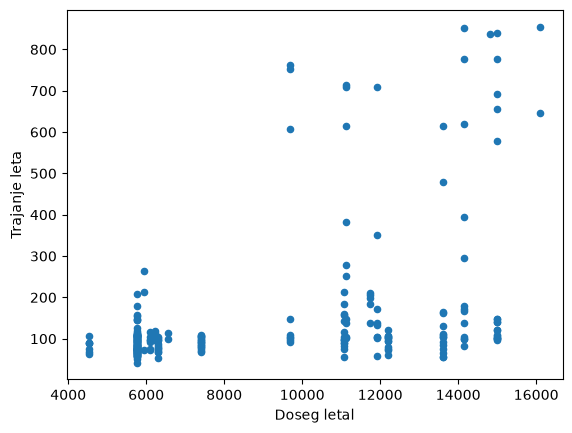

In [ ]:
merged = pd.merge(
    flights,
    aircrafts,
    left_on='equipment',
    right_on='id'
)
ax = merged.plot.scatter(x="range", y="flightDuration")
ax.set_xlabel('Doseg letal')
ax.set_ylabel("Trajanje leta")